In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from log_reg import *

# make matplotlib figures appear inline in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (14.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

np.set_printoptions(precision=3)

# make the notebook automatically reload external python modules
%load_ext autoreload
%autoreload 2

In [2]:
X, y = datasets.load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30)

In [3]:
# First we preprocess the X sets then we add the column of ones
X_train= min_max_scale(X_train)
X_test = min_max_scale(X_test)

# X_train= standaradize(X_train)
# X_test = standaradize(X_test)

X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

In [4]:
theta = np.random.random(size=X_train.shape[1])
theta

array([0.355, 0.957, 0.677, 0.483, 0.493, 0.083, 0.092, 0.602, 0.554,
       0.213, 0.946, 0.781, 0.113, 0.931, 0.974, 0.996, 0.056, 0.737,
       0.546, 0.706, 0.969, 0.688, 0.837, 0.867, 0.838, 0.426, 0.223,
       0.397, 0.892, 0.147, 0.513])

In [5]:
theta, loss = gradient_descent(X_train, y_train, theta, .3, 40_000)
theta

array([ 1.795e+01, -6.222e-01, -3.652e+00, -8.677e-01, -2.676e+00,
       -1.570e+00,  4.962e+00, -5.277e+00, -8.826e+00,  7.888e-01,
        3.815e+00, -1.101e+01, -7.175e-03, -6.922e+00, -5.742e+00,
       -1.563e+00,  5.179e+00,  1.337e+00, -2.140e+00,  3.182e+00,
        3.970e+00, -6.482e+00, -7.346e+00, -3.982e+00, -5.531e+00,
       -3.390e+00,  1.128e+00, -6.142e+00, -4.727e+00, -8.762e+00,
       -7.461e-02])

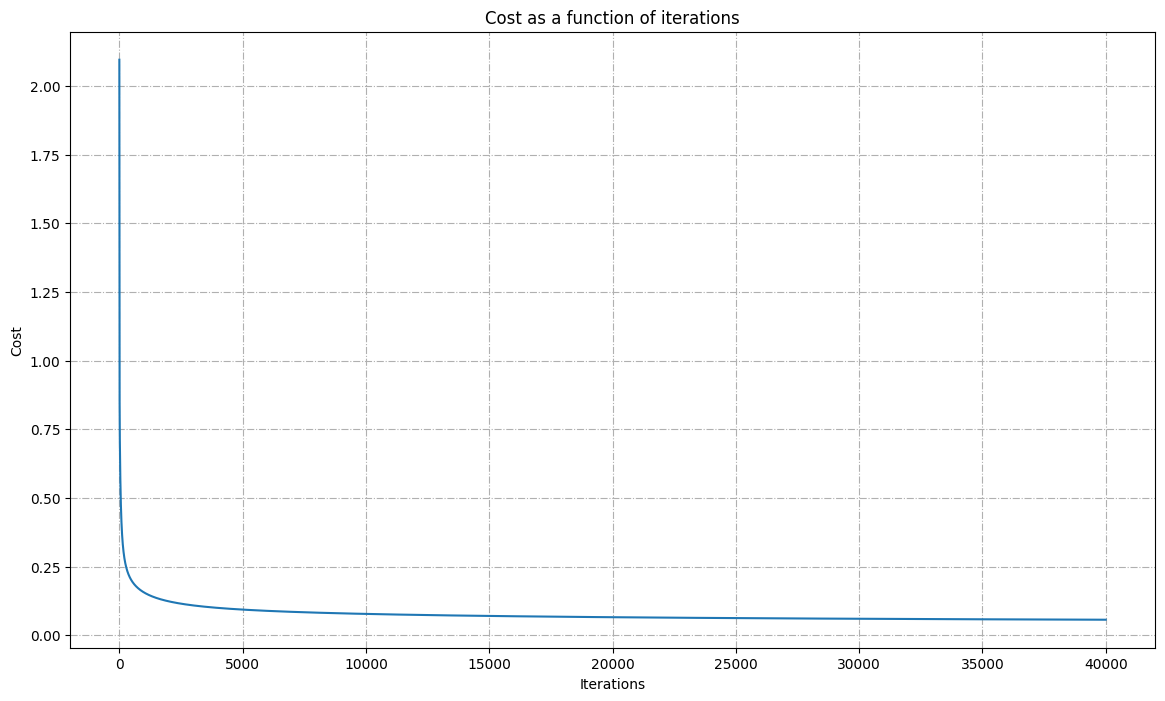

In [6]:
plt.plot(loss)
plt.title('Cost as a function of iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(linestyle='-.')

In [7]:
compute_accuracy(X_test, y_test, theta)

np.float64(84.21)